In [18]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate, binary_dilation
import scipy.ndimage
import base64
from PIL import Image
import openpyxl
import os
import time

In [2]:
folder_path = "C:\\Users\\20212238\\OneDrive - TU Eindhoven\\Documents\\TUE\\M - Jaar 1\\Team Challenge\\Image analysis project\\Aneurysm_TC_data\\"
patient_ID = 'C0001' # HIER PATIENT ID TOEVOEGEN
file_path_3DRA = folder_path + patient_ID + '\\3DRA.nii.gz'
file_path_mask = folder_path + patient_ID + '\\corrected_segmentation.nii.gz'

In [3]:
def load_nifti(file_path_3DRA, file_path_mask):
    nifti_img = nib.load(file_path_3DRA)
    nifti_mask = nib.load(file_path_mask)
    data_image = nifti_img.get_fdata()
    data_mask = nifti_mask.get_fdata()
    return data_image, data_mask

In [4]:
def extract_aneurysm_neck(segmentation):
    aneurysm_mask = segmentation == 2
    blood_vessel_mask = segmentation == 1    
    
    dilated_vessels = binary_dilation(blood_vessel_mask, structure=np.ones((2, 2, 2)))
    aneurysm_neck = dilated_vessels & aneurysm_mask

    dilated_aneurysm = binary_dilation(aneurysm_mask, structure=np.ones((4, 4, 4)))
    aneurysm_neck_vessel = dilated_aneurysm & blood_vessel_mask

    aneurysm_neck_mask = np.zeros_like(segmentation)
    aneurysm_neck_mask[aneurysm_neck | aneurysm_neck_vessel] = 1

    segmentation_substract = (blood_vessel_mask==1) & (aneurysm_neck_mask==1)
    segmentation = segmentation-segmentation_substract
    return aneurysm_neck_mask, segmentation

In [5]:
volume, segmentation = load_nifti(file_path_3DRA, file_path_mask)
aneurysm_neck_seg, segmentation = extract_aneurysm_neck(segmentation)


In [39]:
# def generate_drr(volume,segmentation,aneurysm_neck_seg, angle=0, axis='z'):
#     if axis == 'x':
#         rotated_vol = rotate(volume, angle, axes=(1, 2), reshape=False)     # axes zijn de twee assen waarover wordt geroteerd, dus bijvoorbeeld; axes = (0,1) is een rotatie om de x en y as en daarom een rotatie in de z richting.
#         rotated_seg = rotate(segmentation, angle, axes=(1, 2), reshape=False)
#         rotated_neck = rotate(aneurysm_neck_seg, angle, axes=(1, 2), reshape=False)
#     elif axis == 'y':
#         rotated_vol = rotate(volume, angle, axes=(0, 2), reshape=False)
#         rotated_seg = rotate(segmentation, angle, axes=(0, 2), reshape=False)
#         rotated_neck = rotate(aneurysm_neck_seg, angle, axes=(0, 2), reshape=False)
#     else:  
#         rotated_vol = rotate(volume, angle, axes=(0, 1), reshape=False)
#         rotated_seg = rotate(segmentation, angle, axes=(0, 1), reshape=False)
#         rotated_neck = rotate(aneurysm_neck_seg, angle, axes=(0, 1), reshape=False)

#     drr_img = np.mean(rotated_vol, axis=2)   # axis = 2 betekend hier dat de gemiddeldes worden bepaald over de diepte van het geroteerde volume en dus niet over de breedte of hoogte.

#     rotated_seg_int = np.round(rotated_seg).astype(np.int32)
#     rotated_neck_int = np.round(rotated_neck).astype(np.int32)
#     #count_1 = np.sum((rotated_seg_int == 1) | (rotated_seg_int == 2), axis=2)
#     count_1 = np.sum( (rotated_seg_int == 1), axis=2)
#     count_2 = np.sum(rotated_seg_int == 2, axis=2)
#     count_neck = np.sum(rotated_neck_int == 1, axis=2)

#     return drr_img, count_1, count_2, count_neck


In [327]:
# def depths(drr_vol,angle):
    
#     angle = np.deg2rad(angle%90)
#     d1 = []
#     l = int(drr_vol.shape[1]/2)
#     turn_pt = l*(np.cos(angle)-np.sin(angle))

#     for i in [j + 0.5 for j in range(-l,l)]:
#         if i < turn_pt:
#             d = round(i*np.tan(angle) + l/np.cos(angle),1)
#         else:
#             d = round(-i/np.tan(angle) + l/np.sin(angle),1)
#         d1.append(d)
    
#     d2 = d1[::-1]
#     d_tot = [d1[i] + d2[i] for i in range(len(d1))]
#     d_tot = [min(d, drr_vol.shape[1]) for d in d_tot]
    

#     return d_tot

# depth = depths(volume,30)
# print(depth[128])
# plt.plot(range(-128,128),depth)
# plt.axis('scaled');

In [ ]:
def get_rotation_matrix(alpha, theta, shape):
    """Generate a 3D rotation matrix for given angles."""
    alpha = np.deg2rad(alpha)
    theta = np.deg2rad(theta)

    R_y = np.array([[ np.cos(alpha), 0, np.sin(alpha)],
                    [ 0,            1, 0           ],
                    [-np.sin(alpha), 0, np.cos(alpha)]])

    R_x = np.array([[1, 0,           0          ],
                    [0, np.cos(theta), -np.sin(theta)],
                    [0, np.sin(theta),  np.cos(theta)]])

    R = R_x @ R_y  # Combine rotations (first Y, then X)
    
    # Compute the shift to keep the center stable
    center = np.array(shape) / 2
    shift = center - R @ center
    return R, shift

def generate_drr(volume, segmentation, aneurysm_neck_seg, alpha=0, theta=0, a=1):

    # Get transformation matrix
    R, shift = get_rotation_matrix(alpha, theta, volume.shape)

    # Apply affine transform for rotation
    dimen = np.ones_like(volume)
    rotated_dimen = scipy.ndimage.affine_transform(dimen, R, offset=shift, order=1)
    rotated_vol = scipy.ndimage.affine_transform(volume, R, offset=shift, order=1)
    rotated_seg = scipy.ndimage.affine_transform(segmentation, R, offset=shift, order=0)
    rotated_neck = scipy.ndimage.affine_transform(aneurysm_neck_seg, R, offset=shift, order=0)

    # rotated_dimen = rotate(dimen, theta, axes=(1, 2), reshape=False)
    # rotated_vol = rotate(volume, theta, axes=(1, 2), reshape=False)     # axes zijn de twee assen waarover wordt geroteerd, dus bijvoorbeeld; axes = (0,1) is een rotatie om de x en y as en daarom een rotatie in de z richting.
    # rotated_seg = rotate(segmentation, theta, axes=(1, 2), reshape=False)
    # rotated_neck = rotate(aneurysm_neck_seg, theta, axes=(1, 2), reshape=False)

    # rotated_dimen = rotate(rotated_dimen, alpha, axes=(0, 2), reshape=False)
    # rotated_vol = rotate(rotated_vol, alpha, axes=(0, 2), reshape=False)
    # rotated_seg = rotate(rotated_seg, alpha, axes=(0, 2), reshape=False)
    # rotated_neck = rotate(rotated_neck, alpha, axes=(0, 2), reshape=False)

    # Generate DRR by averaging over depth
    # rotated_vol = (rotated_vol-np.min(rotated_vol))/(np.max(rotated_vol)-np.min(rotated_vol))
    sum_values = np.sum(rotated_vol, axis=2)
    # depth = depths(volume,theta)
    depth = np.sum(rotated_dimen, axis=2)

    # count_nonzero = np.count_nonzero(rotated_dimen, axis=2)
    mask = (depth != 0)
    
    if a == 1:
        drr_img = np.divide(sum_values,depth,where=(mask==1))
        drr_img[mask==0] = 0
    if a == 0:
        drr_img = np.mean(rotated_vol, axis=2)


    # Convert segmentations to integer masks
    rotated_seg_int = np.round(rotated_seg).astype(np.int32)
    rotated_neck_int = np.round(rotated_neck).astype(np.int32)

    # Count segmentation values
    count_1 = np.sum(rotated_seg_int == 1, axis=2)
    count_2 = np.sum(rotated_seg_int == 2, axis=2)
    count_neck = np.sum(rotated_neck_int == 1, axis=2)

    return drr_img, count_1, count_2, count_neck

In [7]:
def calculate_visibility_score(count_aneurysm, count_vessel, count_neck):
    blood_vessel_in_aneurysm = np.count_nonzero(count_vessel & count_aneurysm)
    blood_vessel_in_neck = np.count_nonzero(count_vessel & count_neck)
    
    aneurysm_surface = np.count_nonzero(count_aneurysm)
    neck_surface = np.count_nonzero(count_neck)
    
    aneurysm_visibility = aneurysm_surface / (blood_vessel_in_aneurysm if blood_vessel_in_aneurysm > 0 else 1)
    neck_visibility = neck_surface / (blood_vessel_in_neck if blood_vessel_in_neck > 0 else 1)
    
    return aneurysm_visibility, neck_visibility

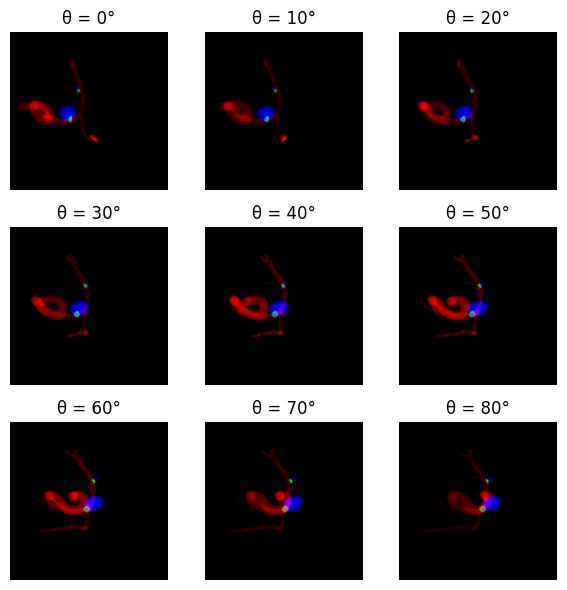

In [317]:
alpha_values = np.arange(0, 45, 45)
theta_values = np.arange(0, 90, 10)  # 0 to 180 degrees in steps of 5 (inclusive)

# alpha = np.arange(0, 180, 45) 
# theta_values = 0  
list_drr = []
# Set up figure for plotting
fig, axes = plt.subplots(3, 3, figsize=(6,6))  # 6x6 grid

for alpha in alpha_values:
    for i, theta in enumerate(theta_values):
        drr_img, count_vessel, count_aneurysm, count_neck = generate_drr(volume, segmentation, aneurysm_neck_seg, alpha, theta)
        # drr_img, count_vessel, count_aneurysm, count_neck = generate_drr(volume,segmentation,aneurysm_neck_seg, theta, axis='x')
        list_drr.append(drr_img)
        # print(256/(np.cos(theta%90)))

        count_1_norm = count_vessel / np.max(count_vessel) 
        count_2_norm = count_aneurysm/ np.max(count_aneurysm) 
        count_neck_norm = count_neck / np.max(count_neck)

        combined_img = np.zeros((*count_vessel.shape, 3))
        combined_img[..., 0] = count_1_norm  
        combined_img[..., 2] = count_2_norm  
        combined_img[..., 1] = count_neck_norm

        ax = axes[i // 3, i % 3]  # Get subplot position
        ax.imshow(combined_img)
        ax.set_title(f'θ = {theta}°')
        ax.axis('off')  # Hide axis for better visualization

plt.tight_layout()
plt.show()

In [ ]:
alpha_values = np.arange(0, 181, 10)
theta_values = np.arange(0, 351, 10) 

for patient_ID in os.listdir(folder_path):
    folder_path = "C:\\Users\\20212238\\OneDrive - TU Eindhoven\\Documents\\TUE\\M - Jaar 1\\Team Challenge\\Image analysis project\\Aneurysm_TC_data\\"

    file_path_3DRA = folder_path + patient_ID + '\\3DRA.nii.gz'
    file_path_mask = folder_path + patient_ID + '\\corrected_segmentation.nii.gz'

    volume, segmentation = load_nifti(file_path_3DRA, file_path_mask)
    aneurysm_neck_seg, segmentation = extract_aneurysm_neck(segmentation)
    
    drr_img_list = []
    combined_img_list = []
    scores = []
    drr_filename_list = []

    wb = openpyxl.Workbook()
    ws = wb.active
    ws.title = "data"
    ws.append(['DRR filename','aneurysm score','neck score','score'])

    for alpha in alpha_values:
        for theta in theta_values:
            drr_img = np.zeros_like(volume)
            drr_img, count_vessel, count_aneurysm, count_neck = generate_drr(volume, segmentation, aneurysm_neck_seg, alpha, theta)
            drr_img[drr_img<0.01] = 0
            
            drr_filename = patient_ID + '_X' + str(theta) + '_Y' + str(alpha)
            drr_filepath = 'dataset2\\DRR_images\\' + drr_filename # Change path

            # drr_img = np.nan_to_num(drr_img, nan=0, posinf=0, neginf=0)
            # drr_img = np.maximum(drr_img, 0)
            drr_img = 255*(drr_img-np.min(drr_img))/(np.max(drr_img)-np.min(drr_img))
            # drr_img = np.clip(drr_img, 0, 255)
            drr_img_uint8 = drr_img.astype(np.uint8)

            # drr_img_uint8 = np.uint8(drr_img/np.max(drr_img) * 255)
            im = Image.fromarray(drr_img_uint8)
            im.save(drr_filepath + '.png')

            count_1_norm = count_vessel / np.max(count_vessel) 
            count_2_norm = count_aneurysm/ np.max(count_aneurysm) 
            count_neck_norm = count_neck / np.max(count_neck)

            combined_img = np.zeros((*count_vessel.shape, 3))
            combined_img[..., 0] = count_1_norm  
            combined_img[..., 2] = count_2_norm  
            combined_img[..., 1] = count_neck_norm

            aneurysm_score, neck_score = calculate_visibility_score(count_aneurysm, count_vessel, count_neck)

            score = aneurysm_score+neck_score
            drr_img_list.append(drr_img)
            combined_img_list.append(combined_img)
            scores.append(score)
            drr_filename_list.append(drr_filename)
            ws.append([drr_filename,aneurysm_score,neck_score,score])

            # time.sleep(2)

    fname = 'dataset2\\excel\\' + patient_ID + '.xlsx' # Change path
    wb.save(filename = fname)

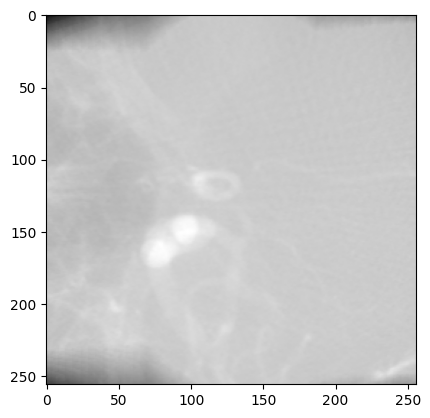

In [74]:
# drr_img_list[5].astype(np.uint8)
plt.imshow(drr_img_list[5],cmap='gray');

In [72]:
scores = np.array(scores)
idx = np.argsort(scores)

scores_sorted = scores[idx]
combined_img_sorted = np.array(combined_img_list)[idx]
drr_img_sorted = np.array(drr_img_list)[idx]
drr_filename_sorted = np.array(drr_filename_list)[idx]


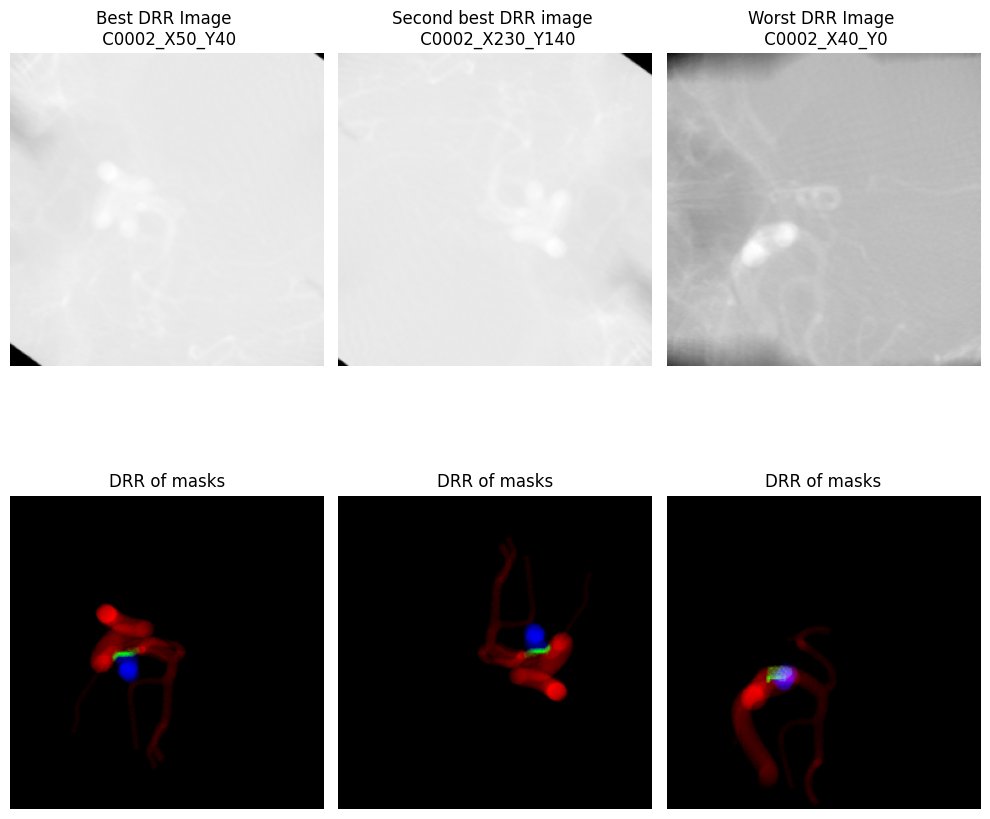

In [73]:
fig, ax = plt.subplots(2, 3, figsize=(10, 10))
ax[0, 0].imshow(drr_img_sorted[-1], cmap='gray')
ax[0, 0].set_title(f"Best DRR Image \n {drr_filename_sorted[-1]}")
ax[0, 0].axis('off')

ax[1, 0].imshow(combined_img_sorted[-1])
ax[1, 0].set_title("DRR of masks")
ax[1, 0].axis('off')

ax[0, 1].imshow(drr_img_sorted[-2], cmap='gray')
ax[0, 1].set_title(f"Second best DRR image \n {drr_filename_sorted[-2]}")
ax[0, 1].axis('off')

ax[1, 1].imshow(combined_img_sorted[-2])
ax[1, 1].set_title("DRR of masks")
ax[1, 1].axis('off')

ax[0, 2].imshow(drr_img_sorted[0], cmap='gray')
ax[0, 2].set_title(f"Worst DRR Image \n {drr_filename_sorted[0]}")
ax[0, 2].axis('off')

ax[1, 2].imshow(combined_img_sorted[0])
ax[1, 2].set_title("DRR of masks")
ax[1, 2].axis('off')

plt.tight_layout()
plt.show()

In [215]:
wb_out = openpyxl.Workbook()
ws_out = wb_out.active
ws_out.title = "data"
ws_out.append(['DRR filename','aneurysm score','neck score','score'])

for patient_id in os.listdir(folder_path):

    excel_path = os.path.join('dataset\\excel\\', patient_id + '.xlsx') 
    wb_in = openpyxl.load_workbook(filename = excel_path)
    ws_in = wb_in.active
    nrrows = ws_in.max_row
    nrcols = ws_in.max_column

    for i in range(2,nrrows+1):
        row = []
        for j in range(1,nrcols+1):
            row.append(ws_in.cell(row=i,column=j).value)
        ws_out.append(row)

fname_out = 'dataset\\excel\\all_DRR_scores.xlsx' # Change path
wb_out.save(filename = fname_out)

In [69]:
for patient_id in os.listdir(folder_path):
    print(patient_id)

C0001
C0002
C0003
C0004
C0005
C0008
C0018
C0036
C0049
C0074


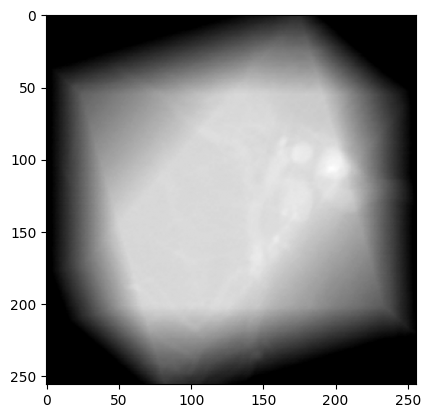

In [355]:
img = np.uint8(drr_img_sorted[-1]/np.max(drr_img_sorted[-1]) * 255)
minval = np.percentile(img, 15)
maxval = np.percentile(img, 100)
pixvals = np.clip(img, minval, maxval)
pixvals = ((pixvals - minval) / (maxval - minval)) * 255

# ft = np.fft.ifftshift(img)
# ft = np.fft.fft2(ft)
# ft = np.fft.fftshift(ft)
# # ft[:,120:136] = 1
# ft[122:134,122:134] = 1

# ift = np.fft.ifftshift(ft)
# ift = np.fft.ifft2(ift)
# ift = np.fft.fftshift(ift).real
plt.imshow(pixvals,cmap='gray')
# np.log(abs(ft))
